<a href="https://colab.research.google.com/github/Jingleeeeee/WQD7013_G7_Stats/blob/khairi-edit/Global%20Air%20Quality%20Index_G7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 - Reproducible Notebook

# WQD7013_G7_Stats
- **Course:** WQD7013 STATISTICS FOR DATA SCIENCE
- **Dataset:** Global Air Quality 2023 (Messy from WAQI786)
- **Group Members:**

| No. | Name | Student ID |
|-----|------|------------|
|1|Nurin Miza Afiqah Binti Andrie Dazlee|s2154141|
|2|Anisah Maisarah Binti Ahmad Nasaruddin|S2121975|
|3|Ng Jing Lee|24215833|
|4|Nur Aliah Natasya|25085928|
|5|Pan Hui Xin|25090880|
|6|Mohd Khairi Bin Yusof|S2191607|

This notebook follows reproducibility rules (no absolute paths).

### This dataset contains global air quality observations:

- **Air quality measurements**: `PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`  
- **Meteorological data**     : `Temperature`, `Humidity`, `Wind Speed`  
- **Location information**    : `City` and `Country`  
- **Temporal data**           : `Date of observation`
- **Colunm added**              : `AQI_level`, `AQI_Category`, `PM2.5_Category`, `PM25_Level`, `PM10_Level`, `Year`, `Month` and `Temp_Category`

# Setup & Library Imports

We import the core libraries used throughout the notebook: `pandas` and `numpy` for data handling..... ## please add relevant packages ##

In [9]:
# Make sure your dataset is in the same folder as this notebook
#Core
import pandas as pd
import numpy as np

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Dataset path
file_path = 'global_air_quality.csv'
kaggle_source = 'https://www.kaggle.com/datasets/coffxc12/global-air-quality-2023-messy-from-waqi786/data'

#Formating
pd.options.display.float_format = '{:.3f}'.format


---
# Task A Dataset Audit and Variable Classification

### A1.1 Load Dataset

In [10]:
# Load the raw dataset
df_raw = pd.read_csv("global_air_quality.csv")
print(f"Dataset loaded successfully! Shape: {df_raw.shape}")

#Create a clean dataset
df_clean = df_raw.copy()

Dataset loaded successfully! Shape: (30450, 12)


In [11]:
df_raw.head()

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Johannesburg,South Africa,4/10/2023,127.510,175.100,NaN,13.020,1.700,196.410,27.460,51.140,10.260
1,Istanbul,Turkey,4/22/2023,93.840,34.190,79.490,44.540,5.180,183.620,10.580,30.480,14.450
2,Berlin,Germany,10/27/2023,52.030,181.800,45.050,30.120,0.960,155.610,-4.090,96.900,2.490
3,SYDNEY,Australia,6/10/2023,110.300,NaN,77.440,9.780,6.540,18.980,17.410,64.790,12.770
4,Dubai,UAE,7/23/2023,120.240,48.980,98.820,6.270,6.980,133.940,13.110,31.610,5.000


**What we found:**
> The csv file loads as expected with a datasets contains 30450 rows × 12 columns that satisfying the minimum size requirement for our analysis and matching the Kaggle dataset description.

### A1.2 Data Types

In [12]:
df_raw.dtypes

,0
City,object
Country,object
Date,object
PM2.5,float64
PM10,float64
NO2,float64
SO2,float64
CO,float64
O3,float64
Temperature,float64


**Justification for A1.2:**
- Categorical variables such as `country_name`,`city_name` and `Date` are stored as `object` types.
- Numerical variables such as pollutant concentrations (e.g., `PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`, `Temperature`, `Humidity`, `Wind Speed`) are stored as numeric types `float64`.

### A1.3 Missing Value

In [13]:
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100

pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_pct
})

,Missing Count,Missing %
City,0,0.000
Country,0,0.000
Date,0,0.000
PM2.5,1552,5.097
PM10,1561,5.126
NO2,1593,5.232
SO2,1475,4.844
CO,1496,4.913
O3,1600,5.255
Temperature,0,0.000


**What we found:**
- Missing values were assessed for each column.

- Columns such as `PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3` contain  missing values.

### A1.4 Duplicate Rows

In [14]:
duplicate_count = df_raw.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 10495


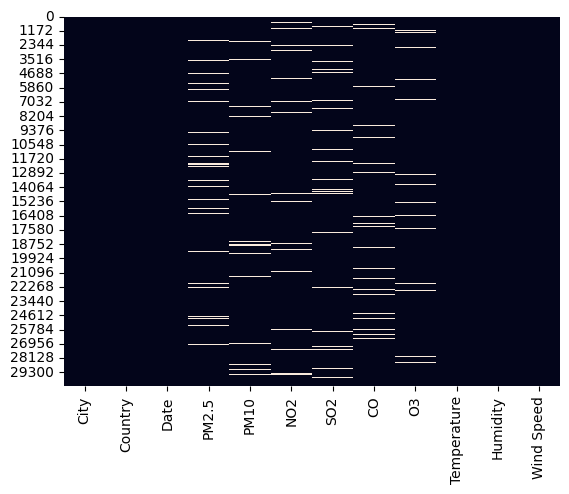

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_raw.isnull(), cbar=False)
plt.show()

**What we found:**
- A total of 10495 duplicate rows were identified in the dataset.

### A1.5 Column with Wrong Inferred dtype

In [16]:
# Convert to table format
wrong_dtype = df_raw[["City", "Country", "Date"]].dtypes.reset_index()
wrong_dtype.columns = ["Column", "Inferred dtype"]

wrong_dtype

,Column,Inferred dtype
0,City,object
1,Country,object
2,Date,object


### Justification for A1.5
The following columns `City`, `Country`, and `Date`were identified as having incorrect inferred data types and require conversion to ensure accurate and efficient analysis.


### A1.6 Column with Corrected inferred dtype for Variable Classification purpose

#### Issue 1: Incorrect Data Type for Date
- The `Date` variable is stored as an object instead of a datetime type.
- This prevents proper time-based analysis and must be corrected.

In [17]:
#Correct the data type for data
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce") # errors="coerce" to safe handling any invalid dates
#Show before and after
print("Before:", df_raw["Date"].dtype)
print("After :", df_clean["Date"].dtype)

Before: object
After : datetime64[ns]


In [18]:
#Check
df_clean["Date"].isna().sum()

np.int64(0)

In [19]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Day"] = df_clean["Date"].dt.day

#Show the cleaned output for date
df_clean[["Date", "Year", "Month", "Day"]].head()

,Date,Year,Month,Day
0,2023-04-10,2023,4,10
1,2023-04-22,2023,4,22
2,2023-10-27,2023,10,27
3,2023-06-10,2023,6,10
4,2023-07-23,2023,7,23


#### After Conversion
- The `Date` variable was initially stored as an `object` dtype.
- It was converted to datetime format using `pd.to_datetime()` to enable chronological analysis such as `Year`, `Month`, and`Day`.
- No missing or invalid date values were detected which indicating that no significant conversion errors and can proceed for variable classification.

#### Issue 2: Data Type Improvement for `City` and `Country`
- The `City` and `Country` variables are stored as an object instead of a category type.
- While this is acceptable for string data, they were converted to categorical types to improve memory efficiency and better reflect their nominal categorical nature.

In [20]:
df_clean["City"] = df_clean["City"].astype("category")
df_clean["Country"] = df_clean["Country"].astype("category")
df_clean[["City", "Country"]].dtypes

,0
City,category
Country,category


#### After convertion
- The `City` and `Country` variables were converted from `object` to `categorical` dtype to improve memory efficiency and better reflect their nominal categorical nature.
- The conversion was successful and can proceed for variable classification.

---
## A2 Variable Classification

### A2.1 Additional Variable Transformations

#### Issue 3: Negative Temperature Values
- The `Temperature` variable includes negative values.
- While negative temperatures are valid in some geographical regions, they may be unrealistic depending on the location and context of the dataset.
- These values should be verified to ensure they are not data entry errors or unit inconsistencies (e.g., Celsius vs Kelvin).

In [21]:
#Check negative temperature
df_raw[df_raw["Temperature"] < 0]

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
2,Berlin,Germany,10/27/2023,52.030,181.800,45.050,30.120,0.960,155.610,-4.090,96.900,2.490
5,Johannesburg,South Africa,7/25/2023,119.390,148.610,38.320,21.480,1.790,96.780,-2.620,89.280,9.270
14,London,UK,3/23/2023,21.330,190.160,26.620,40.190,2.630,14.070,-8.780,44.950,2.390
15,Seoul,South Korea,6/5/2023,79.710,195.270,91.260,NaN,1.240,NaN,-6.260,58.000,1.090
17,Beijing,China,4/3/2023,105.580,148.880,95.050,39.390,2.380,170.410,-5.820,29.380,13.340
...,...,...,...,...,...,...,...,...,...,...,...,...
30421,Los Angeles,USA,9/1/2023,64.880,173.950,73.250,NaN,9.190,192.190,-3.570,47.090,6.230
30427,NEW YORK,USA,11/26/2023,105.260,62.740,17.200,44.340,1.040,49.280,-4.520,82.350,11.780
30429,Berlin,Germany,7/14/2023,141.170,173.070,21.120,28.460,1.880,183.970,-5.970,11.950,13.200
30430,Sydney,Australia,8/12/2023,59.760,74.140,39.800,25.540,7.720,NaN,-1.260,12.270,17.070


In [22]:
# Define classification functions for temperature
def temp_category(temp):
    if temp < 10:
        return "Cold"
    elif temp <= 28:
        return "Neutral"
    else:
        return "Hot"

df_clean["Temp_Category"] = df_clean["Temperature"].apply(temp_category)

#Clean view
df_clean["Temp_Category"] = pd.Categorical(
    df_clean["Temp_Category"],
    categories=["Cold", "Neutral", "Hot"],
    ordered=True
)

#Show result
df_clean[["Temperature", "Temp_Category"]].head()

#Step 5: View result
[
    df_clean[["Temperature", "Temp_Category"]].head(),
    df_clean["Temp_Category"].value_counts()
]

[   Temperature Temp_Category
 0       27.460       Neutral
 1       10.580       Neutral
 2       -4.090          Cold
 3       17.410       Neutral
 4       13.110       Neutral,
 Temp_Category
 Cold       12325
 Neutral    10936
 Hot         7189
 Name: count, dtype: int64]

In [23]:
# Determmine the temperature type
df_clean["Temperature"].describe()

,Temperature
count,30450.000
mean,14.801
std,14.487
min,-10.000
25%,2.020
50%,14.660
75%,27.230
max,40.000


#### Justification for Issue 3:
- Negative temperature values were identified and retained because it may represent valid observations depending on geographic context.
- Instead to remove the negative values, we created a `Temp_Category` with 3 different threshold such as `Hot`,`Cold`, and `Neutral` to support our data analysis.
- The descriptive statistics show the temperature values range from -10 to 40, which looks realistic for everyday weather conditions in Celsius.
- Since there are negative values, this also confirms that the data is **NOT** recorded in Kelvin as it represented a absolute scale.

#### Issue 4: Lack of AQI Category Classification
- The dataset does not include categorical air quality classifications (e.g., “Good”, “Moderate”, “Unhealthy”) for pollutant variables such as `PM2.5` and `PM10`.
- Without defined thresholds, it is not possible to directly interpret air quality levels.
- For meaningful analysis, standard AQI breakpoints should be applied to derive categorical variables, enabling better interpretation and comparison.

In [24]:
#Step 1: Define classification functions for both AQI
def classify_pm25(pm25):
    if pm25 <= 5:
        return 1
    elif pm25 <= 15:
        return 2
    elif pm25 <= 25:
        return 3
    elif pm25 <= 50:
        return 4
    elif pm25 <= 100:
        return 5
    else:
        return 6

def classify_pm10(pm10):
    if pm10 <= 15:
        return 1
    elif pm10 <= 45:
        return 2
    elif pm10 <= 75:
        return 3
    elif pm10 <= 150:
        return 4
    elif pm10 <= 250:
        return 5
    else:
        return 6


#Step 2: Apply classification
df_clean["PM25_Level"] = df_clean["PM2.5"].apply(classify_pm25)
df_clean["PM10_Level"] = df_clean["PM10"].apply(classify_pm10)


#Step 3: Combine (with worst cases)
df_clean["AQI_Level"] = df_clean[["PM25_Level", "PM10_Level"]].max(axis=1)


#Step 4: Map to category labels
labels = {
    1: "Very Good",
    2: "Good",
    3: "Moderate",
    4: "Unhealthy",
    5: "Very Unhealthy",
    6: "Hazardous"
}
df_clean["AQI_Category"] = df_clean["AQI_Level"].map(labels)

#Step 5: Change type from object to category as ordinal order
df_clean["AQI_Category"] = pd.Categorical(
    df_clean["AQI_Category"],
    categories=[
        "Very Good",
        "Good",
        "Moderate",
        "Unhealthy",
        "Very Unhealthy",
        "Hazardous"
    ],
    ordered=True
)
#Step 5: View result
[
    df_clean[["PM2.5", "PM10", "AQI_Category"]].head(),
    df_clean["AQI_Category"].value_counts()
]

[    PM2.5    PM10    AQI_Category
 0 127.510 175.100       Hazardous
 1  93.840  34.190  Very Unhealthy
 2  52.030 181.800  Very Unhealthy
 3 110.300     NaN       Hazardous
 4 120.240  48.980       Hazardous,
 AQI_Category
 Hazardous         12649
 Very Unhealthy    11515
 Unhealthy          4914
 Moderate           1015
 Good                357
 Very Good             0
 Name: count, dtype: int64]

#### Justification for Issue 4:
> A categorical AQI variable was created from PM2.5 values using standard thresholds to improve interpretability.
- Air quality categories `AQI_Category` were derived using both `PM2.5` and `PM10` concentrations based on thresholds aligned with WHO Air Quality Guidelines.
- Each pollutant was first classified into risk levels such as `Very Good`,`Good`, `Moderate`, `Unhealthy`, `Very Unhealthy`, `Hazardous`  and the overall air quality category was determined using the maximum (worst case) level.
- This approach reflects real-world air quality assessment practices, where the most hazardous pollutant determines overall risk.
- The resulting categories provide a more comprehensive and health-relevant interpretation of air quality conditions.

### A2.2 Classification Table

In [25]:
# Step 1: Create classification table
classification = pd.DataFrame({
    "Variable": [
        "City", "Country", "Date",
        "PM2.5", "PM10", "NO2", "SO2", "CO", "O3",
        "Temperature", "Humidity", "Wind Speed",
        "PM25_Level", "PM10_Level", "AQI_Level", "AQI_Category",
        "Year", "Month", "Day"
    ],

    "Measurement Type": [
        "Nominal categorical", "Nominal categorical", "Continuous (temporal)",
        "Continuous numerical", "Continuous numerical", "Continuous numerical", "Continuous numerical", "Continuous numerical", "Continuous numerical",
        "Continuous numerical", "Continuous numerical", "Continuous numerical",
        "Ordinal categorical", "Ordinal categorical", "Ordinal categorical", "Ordinal categorical",
        "Discrete numerical", "Discrete numerical", "Discrete numerical"
    ],

    "Role": [
        "Identifier", "Identifier", "Feature",
        "Feature", "Feature", "Feature", "Feature", "Feature", "Feature",
        "Feature", "Feature", "Feature",
        "Derived", "Derived", "Derived", "Derived",
        "Derived", "Derived", "Derived"
    ],

    "Summary Statistic": [
        "Mode", "Mode", "Min/Max",
        "Mean/Median", "Mean/Median", "Mean/Median", "Mean/Median", "Mean/Median", "Mean/Median",
        "Mean/Median", "Mean/Median", "Mean/Median",
        "Frequency", "Frequency", "Frequency", "Frequency",
        "Mode", "Mode", "Mode"
    ],

    "Visualisation": [
        "Bar chart", "Bar chart", "Line plot",
        "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot",
        "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot",
        "Bar chart", "Bar chart", "Bar chart", "Bar chart",
        "Bar chart", "Bar chart", "Bar chart"
    ]
})

# Step 2: Add Pandas dtype automatically (safe method)
classification["Pandas dtype"] = df_clean[classification["Variable"]].dtypes.values

# Step 3: Reorder columns (optional but cleaner)
classification = classification[
    ["Variable", "Pandas dtype", "Measurement Type", "Role", "Summary Statistic", "Visualisation"]
]

# Step 4: Display nicely
classification.style.set_caption("Variable Classification Table")

,Variable,Pandas dtype,Measurement Type,Role,Summary Statistic,Visualisation
0,City,category,Nominal categorical,Identifier,Mode,Bar chart
1,Country,category,Nominal categorical,Identifier,Mode,Bar chart
2,Date,datetime64[ns],Continuous (temporal),Feature,Min/Max,Line plot
3,PM2.5,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
4,PM10,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
5,NO2,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
6,SO2,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
7,CO,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
8,O3,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
9,Temperature,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot


### Justification for A2.2

> Overall, this classification ensures that appropriate statistical methods and visualisations are applied, improving the accuracy and interpretability of the analysis.

---
## A3 Missing Data Diagnosis

### A3.1 Misssing Data Pattern - Numerical summary

In [26]:
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_pct
})

missing_summary

,Missing Count,Missing %
City,0,0.000
Country,0,0.000
Date,0,0.000
PM2.5,1552,5.097
PM10,1561,5.126
NO2,1593,5.232
SO2,1475,4.844
CO,1496,4.913
O3,1600,5.255
Temperature,0,0.000


### Justification for A3.1 ###
- Missing data analysis shows that pollutant variables (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`) contain approximately 4.8% to 5.3% missing values, while remaining variables have no missing observations.

### A3.2 Visualization - Missing Data Pattern

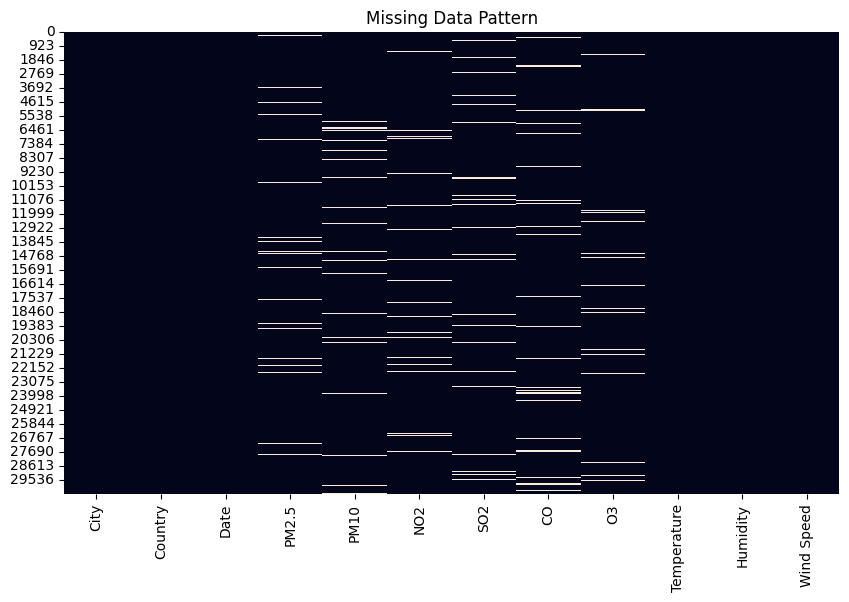

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(df_raw.isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

#### What we found ####
- The heatmap shows that missing values are primarily concentrated within the air pollutant variables (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, and `O3`), while other variables such as `Temperature`, `Humidity`, and `Wind Speed` remain complete.

- The missing values appear as scattered gaps across different observations rather than forming large continuous blocks. The missing values do not follow any obvious pattern.

- Overall, the pattern is more consistent with **Missing at Random (MAR)**.

### A3.3 Classify missingness (MCAR / MAR / MNAR)

In [28]:
print("Missing < 5% (excluding 0):")
print(missing_summary[(missing_summary["Missing %"] > 0) & (missing_summary["Missing %"] < 5)])

print("\nMissing ≥ 5%:")
print(missing_summary[missing_summary["Missing %"] >= 5])

Missing < 5% (excluding 0):
     Missing Count  Missing %
SO2           1475      4.844
CO            1496      4.913

Missing ≥ 5%:
       Missing Count  Missing %
PM2.5           1552      5.097
PM10            1561      5.126
NO2             1593      5.232
O3              1600      5.255


#### Justification for A3.3

- The missingness pattern varies across variables and is concentrated in pollutant measurements.
- Variables such as `City`, `Country`, `Date`, `Temperature`, `Humidity`, and `Wind Speed` contain **no missing values** and therefore do not show any missingness mechanism.
- Variables such as `SO2` and `CO` show **less than 5% missing values**.
- `PM2.5`, `PM10`, `NO2`, `O3` exhibit **more than 5% missing values**.
- The missing values are scattered across observations rather than forming clear or continuous blocks.

### A3.4 Compare handling strategies - for `PM2.5`

In [29]:
# Method 1: Listwise deletion (PM2.5 only)
pm25_drop = df_clean["PM2.5"].dropna()

mean_drop = pm25_drop.mean()
std_drop = pm25_drop.std()

# Method 2: Median imputation
pm25_impute = df_clean["PM2.5"].copy()

median_value = pm25_impute.median()
pm25_impute = pm25_impute.fillna(median_value)

mean_impute = pm25_impute.mean()
std_impute = pm25_impute.std()

# Compare results
print("Listwise Deletion → Mean:", mean_drop, "Std:", std_drop)
print("Median Imputation → Mean:", mean_impute, "Std:", std_impute)

Listwise Deletion → Mean: 77.65102740674094 Std: 42.011750090939756
Median Imputation → Mean: 77.68206600985222 Std: 40.92728736407015


### Justification for A3.4 ###
> The analysis is conducted on the cleaned dataset (df_clean) to ensure consistency after preprocessing.

- Listwise deletion reduces the dataset size and may introduce bias if missingness is not completely random.
- Median imputation preserves all observations and provides a robust estimate of central tendency.
- Both methods produce similar mean values, but median imputation results in a slightly lower standard deviation. This is because imputing with the median reduces variability in the dataset by replacing them with a central value.
- Therefore, median imputation is preferred as it retains all data while providing stable results.

### A3.5 Data Cleaning

#### Good structral quality, but need to improve
- The dataset demonstrates generally good structural quality and is suitable for statistical analysis.
- It contains a sufficient number of observations and well-defined variables.
- Most numerical variables are correctly typed and key contextual variables such as `City` and `Country` are complete.
- However, several data quality issues necessary to conduct a data preprossesing before the analysis.

In [30]:
summary_table = pd.DataFrame({
    "Aspect": ["Rows", "Columns", "Duplicate Rows", "Missing Values"],
    "Observation": [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.duplicated().sum(),
        "Present (~5% in pollutant variables)"
    ]
})

summary_table

,Aspect,Observation
0,Rows,30450
1,Columns,12
2,Duplicate Rows,10495
3,Missing Values,Present (~5% in pollutant variables)


### A3.5.1 Key Data Quality Issues

#### Issues 5: Duplicate and Near-Duplicate Rows
- The dataset includes duplicate and near-duplicate observations.
- These duplicates can bias statistical summaries by over-representing certain records.
- Removing duplicate rows is necessary to ensure each observation contributes equally to the analysis.

In [31]:
#Step 1: Count duplicates
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows (excluding first occurrence):", duplicate_count)

Duplicate rows (excluding first occurrence): 10495


In [32]:
# Step 2: Show ALL duplicate rows (both original + repeated)
duplicates_full = df_clean[df_clean.duplicated(keep=False)].copy()
duplicates_full = duplicates_full.sort_values(by=["City", "Date"]).reset_index(drop=True)
duplicates_full["Duplicate Flag"] = "Yes"
duplicates_full.head(10)

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,...,Wind Speed,Year,Month,Day,Temp_Category,PM25_Level,PM10_Level,AQI_Level,AQI_Category,Duplicate Flag
0,BANGKOK,Thailand,2023-03-25,75.500,157.400,79.920,49.200,7.990,77.180,20.770,...,3.140,2023,3,25,Neutral,5,5,5,Very Unhealthy,Yes
1,BANGKOK,Thailand,2023-03-25,75.500,157.400,79.920,49.200,7.990,77.180,20.770,...,3.140,2023,3,25,Neutral,5,5,5,Very Unhealthy,Yes
2,BANGKOK,Thailand,2023-05-07,76.490,114.470,72.370,21.860,0.640,103.550,8.030,...,11.080,2023,5,7,Cold,5,4,5,Very Unhealthy,Yes
3,BANGKOK,Thailand,2023-05-07,76.490,114.470,72.370,21.860,0.640,103.550,8.030,...,11.080,2023,5,7,Cold,5,4,5,Very Unhealthy,Yes
4,BANGKOK,Thailand,2023-06-05,82.040,109.580,97.120,9.640,8.530,46.720,3.030,...,3.350,2023,6,5,Cold,5,4,5,Very Unhealthy,Yes
5,BANGKOK,Thailand,2023-06-05,82.040,109.580,97.120,9.640,8.530,46.720,3.030,...,3.350,2023,6,5,Cold,5,4,5,Very Unhealthy,Yes
6,BANGKOK,Thailand,2023-07-20,27.080,139.490,67.300,10.860,1.610,85.500,21.440,...,19.050,2023,7,20,Neutral,4,4,4,Unhealthy,Yes
7,BANGKOK,Thailand,2023-07-20,27.080,139.490,67.300,10.860,1.610,85.500,21.440,...,19.050,2023,7,20,Neutral,4,4,4,Unhealthy,Yes
8,BANGKOK,Thailand,2023-08-12,148.440,193.880,24.880,7.260,9.120,10.370,36.000,...,11.480,2023,8,12,Hot,6,5,6,Hazardous,Yes
9,BANGKOK,Thailand,2023-08-12,148.440,193.880,24.880,7.260,9.120,10.370,36.000,...,11.480,2023,8,12,Hot,6,5,6,Hazardous,Yes


In [33]:
# Step 3: Remove duplicates
df_clean = df_clean.drop_duplicates()

In [34]:
# Step 4: Verify removal
duplicate_after = df_clean.duplicated().sum()
print("\nDuplicate rows AFTER removal:", duplicate_after)


Duplicate rows AFTER removal: 0


In [35]:
# Step 5: Show dataset shape change
print("\nDataset shape BEFORE:", df_raw.shape)
print("Dataset shape AFTER :", df_clean.shape)


Dataset shape BEFORE: (30450, 12)
Dataset shape AFTER : (19955, 20)


#### After clean the duplicate
- A sample of duplicate rows is presented to provide visual evidence of repeated observations within the dataset.
- Displaying both the original and duplicated entries allows verification that the rows are identical across all variables.
- This supports the decision to remove duplicates, as their presence would otherwise bias statistical summaries by over-representing certain observations.
- The table also demonstrates that duplicate detection was performed after standardisation, ensuring that inconsistencies in formatting did not mask near-duplicate records.

#### Issues 6 : Missing Values
- Several pollutant variables (PM2.5, PM10, NO2, and O3) contain approximately 5% missing values.
- The missingness appears scattered and is most consistent with **Missing at Random (MAR)**.This level of missingness is moderate and may introduce bias if not handled properly.
- **Median imputation** is preferred due to the skewed distribution of environmental data.

In [36]:
#Median imputation to fill in the missing values
missing_before = df_clean["PM2.5"].isnull().sum()
print("Missing before:", missing_before)

#Assign a list and use for loop
var_to_impute = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]

for col in var_to_impute:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

missing_after = df_clean["PM2.5"].isnull().sum()

print("Missing after:", missing_after)

#Result data clean for no missing value
df_clean[var_to_impute].isnull().sum()

Missing before: 1491
Missing after: 0


,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0


#### After median imputation
- Missing values in pollutant variables (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, and `O3`) were handled simultaneously using median imputation.
- This approach ensures consistency across variables and is appropriate given the skewed distribution of environmental data.
    

#### Issue 7: Inconsistent Variables Formatting
- Inconsistent formatting is present in variables such as `Country` and `City`, including differences in type, capitalisation, spacing, and naming conventions (e.g., "USA" vs "usa").
- This can lead to incorrect grouping and aggregation.
- Standardisation is required before analysis.

In [37]:
# Standardisation

print("Before unique City:", df_raw["City"].nunique())

df_clean["City"] = df_clean["City"].str.strip().str.lower()

print("After unique City :", df_clean["City"].nunique())

df_clean["City"].value_counts().head(10)

Before unique City: 120
After unique City : 20


,count
City,
johannesburg,1071
mumbai,1062
dubai,1049
toronto,1047
berlin,1031
seoul,1027
madrid,1027
cairo,1011
bangkok,1009


In [38]:
# Before Standardisation for City
list(df_raw["City"].unique())
df_raw["City"].unique().tolist()

['Johannesburg',
 'Istanbul',
 'Berlin',
 'SYDNEY',
 'Dubai',
 'Los Angeles',
 'Mumbai',
 'Beijing',
 'Paris',
 'New York',
 'London',
 'Seoul   ',
 'Toronto',
 'Tokyo',
 'london',
 'Mexico City',
 'Madrid',
 'Seoul',
 'Bangkok',
 'New York   ',
 'Rio de Janeiro',
 'MOSCOW',
 'BERLIN',
 'BANGKOK',
 'Moscow',
 'MADRID',
 'johannesburg',
 'MEXICO CITY',
 'Berlin   ',
 'LONDON',
 'tokyo',
 'Paris   ',
 'berlin',
 'istanbul',
 'Cairo',
 'rio de janeiro',
 'Mexico City   ',
 'bangkok',
 'cairo',
 'dubai',
 'new york',
 'toronto',
 'los angeles',
 'mexico city',
 'RIO DE JANEIRO',
 'BEIJING',
 'Sydney',
 'sydney',
 'ISTANBUL',
 'Beijing   ',
 'CAIRO',
 'MUMBAI',
 'DUBAI',
 'madrid',
 'Sydney   ',
 'NEW YORK   ',
 'beijing',
 'moscow',
 'JOHANNESBURG',
 'Moscow   ',
 'TOKYO',
 'TORONTO',
 'PARIS',
 'LOS ANGELES',
 'SEOUL',
 'Cairo   ',
 'Rio de Janeiro   ',
 'mumbai',
 'new york   ',
 'MUMBAI   ',
 'Bangkok   ',
 'Johannesburg   ',
 'NEW YORK',
 'Los Angeles   ',
 'Madrid   ',
 'paris',
 'Ist

In [39]:
# After Standardisation for City
list(df_clean["City"].unique())
df_clean["City"].unique().tolist()

['johannesburg',
 'istanbul',
 'berlin',
 'sydney',
 'dubai',
 'los angeles',
 'mumbai',
 'beijing',
 'paris',
 'new york',
 'london',
 'seoul',
 'toronto',
 'tokyo',
 'mexico city',
 'madrid',
 'bangkok',
 'rio de janeiro',
 'moscow',
 'cairo']

#### After standardization
- The `City` variable was standardised by removing whitespace and converting text to lowercase, reducing the number of unique categories and ensuring consistent grouping.

In [40]:
# Convert `City` from `object` to `category` type
df_clean["City"] = df_clean["City"].astype("category")

# Check dtype for `City` and `Country`
df_clean[["City", "Country"]].dtypes

,0
City,category
Country,category


#### After covertion
- `City` and `Country` were treated as categorical variables.

#### Why convert?
- As `City` was initially stored as an `object` type, it was converted to a categorical type for analytical consistency.

---
## A4 Data Quality Narrative

#### Overall Dataset Quality

After going through a structured cleaning and validation process, the dataset can generally be adequate for statistical analysis.

### A4.1 Overview of the Final Cleaned Dataset: `df_clean`

In [41]:
# FINAL CLEANED DATASET (PREVIEW)
df_clean.head()
df_clean.info()

df_clean[[
    "City", "Country", "Date",
    "PM2.5", "PM10",
    "AQI_Category"
]].head
df_clean.head().style.set_caption("Final Cleaned Dataset (Preview)")

<class 'pandas.core.frame.DataFrame'>
Index: 19955 entries, 0 to 30449
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   City           19955 non-null  category      
 1   Country        19955 non-null  category      
 2   Date           19955 non-null  datetime64[ns]
 3   PM2.5          19955 non-null  float64       
 4   PM10           19955 non-null  float64       
 5   NO2            19955 non-null  float64       
 6   SO2            19955 non-null  float64       
 7   CO             19955 non-null  float64       
 8   O3             19955 non-null  float64       
 9   Temperature    19955 non-null  float64       
 10  Humidity       19955 non-null  float64       
 11  Wind Speed     19955 non-null  float64       
 12  Year           19955 non-null  int32         
 13  Month          19955 non-null  int32         
 14  Day            19955 non-null  int32         
 15  Temp_Category  19955 non

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed,Year,Month,Day,Temp_Category,PM25_Level,PM10_Level,AQI_Level,AQI_Category
0,johannesburg,South Africa,2023-04-10 00:00:00,127.510000,175.100000,52.170000,13.020000,1.700000,196.410000,27.460000,51.140000,10.260000,2023,4,10,Neutral,6,5,6,Hazardous
1,istanbul,Turkey,2023-04-22 00:00:00,93.840000,34.190000,79.490000,44.540000,5.180000,183.620000,10.580000,30.480000,14.450000,2023,4,22,Neutral,5,2,5,Very Unhealthy
2,berlin,Germany,2023-10-27 00:00:00,52.030000,181.800000,45.050000,30.120000,0.960000,155.610000,-4.090000,96.900000,2.490000,2023,10,27,Cold,5,5,5,Very Unhealthy
3,sydney,Australia,2023-06-10 00:00:00,110.300000,103.195000,77.440000,9.780000,6.540000,18.980000,17.410000,64.790000,12.770000,2023,6,10,Neutral,6,6,6,Hazardous
4,dubai,UAE,2023-07-23 00:00:00,120.240000,48.980000,98.820000,6.270000,6.980000,133.940000,13.110000,31.610000,5.000000,2023,7,23,Neutral,6,3,6,Hazardous


In [42]:
# Check df_clean shape
print(f"Final cleaned dataset contains {df_clean.shape[0]} rows and {df_clean.shape[1]} columns.")

Final cleaned dataset contains 19955 rows and 20 columns.


### After preprocessing, the dataset `df_clean` is cleaned and ready for descriptive statistical analysis in Task B.

---
# Task B – Descriptive Statistics and Distribution Shape

## B1. Univariate Summaries

This section computes key descriptive statistics for all numerical variables, including measures of central tendency, dispersion, and distribution shape.

We report:
- Mean and median (centre)
- Standard deviation and IQR (spread)
- Min, max, 5th and 95th percentiles (range and tails)
- Skewness and excess kurtosis (shape)

These statistics help determine whether distributions are symmetric, skewed, or heavy-tailed, which directly affects the choice of appropriate summary measures.

In [43]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# Select numerical columns
num_cols = ["PM2.5", "PM10", "NO2", "SO2", "CO",
    "O3", "Temperature", "Humidity", "Wind Speed"]

summary_list = []

for col in num_cols:
    data = df_clean[col].dropna()

    summary = {
        "Variable": col,
        "Mean": data.mean(),
        "Median": data.median(),
        "Std Dev": data.std(),
        "IQR": data.quantile(0.75) - data.quantile(0.25),
        "Min": data.min(),
        "Max": data.max(),
        "5th Percentile": data.quantile(0.05),
        "95th Percentile": data.quantile(0.95),
        "Skewness": skew(data),
        "Excess Kurtosis": kurtosis(data)
    }

    summary_list.append(summary)

summary_df_clean = pd.DataFrame(summary_list)
summary_df_clean

,Variable,Mean,Median,Std Dev,IQR,Min,Max,5th Percentile,95th Percentile,Skewness,Excess Kurtosis
0,PM2.5,77.764,78.350,40.396,66.560,5.020,149.980,12.620,142.060,-0.023,-1.059
1,PM10,104.178,103.195,52.903,87.350,10.000,200.000,19.630,189.740,0.023,-1.051
2,NO2,52.095,52.170,26.214,43.415,5.010,100.000,9.630,94.760,0.000,-1.032
3,SO2,25.183,25.170,13.533,22.350,1.000,49.990,3.550,47.170,0.019,-1.049
4,CO,5.040,5.080,2.751,4.570,0.100,10.000,0.650,9.450,-0.000,-1.061
5,O3,105.439,105.390,52.868,87.955,10.040,200.000,19.930,190.873,0.002,-1.044
6,Temperature,14.914,14.850,14.454,25.150,-10.000,40.000,-7.550,37.530,0.002,-1.201
7,Humidity,54.753,54.590,25.996,44.865,10.010,99.990,14.507,95.443,0.010,-1.200
8,Wind Speed,10.259,10.330,5.629,9.785,0.500,20.000,1.467,19.030,-0.014,-1.208


### Interpretation:
- **Central Tendency**
  - For all variables, the mean and median are very close (e.g., PM2.5: 77.76 vs 78.35), indicating **approximately symmetric distributions**.
  - This suggests that **extreme values are not heavily distorting the mean**, so both mean and median are reasonable measures of centre.

- **Spread**
  - Variables such as PM10, O3, and PM2.5 show relatively large standard deviations and IQRs, indicating **substantial variability in pollution levels**.
  - Wind Speed and CO have smaller spread, suggesting **more stable measurements**.

- **Skewness**
  - All skewness values are close to 0 (between approximately -0.02 and 0.02), indicating **minimal skewness and near-symmetric distributions**.
  - No variable shows strong right or left skew.

- **Kurtosis**
  - All variables have **negative excess kurtosis (≈ -1)**, indicating **platykurtic distributions** (flatter than normal with lighter tails).
  - This suggests **lighter tails and fewer extreme outliers than expected under a normal distribution**.

- **Outliers and Distribution Shape**
  - The combination of near-zero skewness and negative kurtosis suggests **relatively uniform or evenly spread data**, rather than strongly peaked distributions.
  - Extreme pollution events exist (based on max values), but they are not frequent.

- **Choice of Summary Measures**
  - Given the near symmetry, **mean is an appropriate measure of centre** for most variables.
  - However, due to moderate variability in some variables, **IQR remains a robust measure of spread**, especially for pollution indicators.

- **Practical Insight**
  - Pollution variables (PM2.5, PM10, O3) show **wide ranges**, indicating fluctuating air quality conditions across observations.
  - Environmental factors like temperature and humidity are more **balanced and stable** in comparison.

### Recommendation of Summary Measures:
- For all variables, skewness is near zero and no statistically defined outliers are detected under standard criteria.
- Therefore, the **mean is an appropriate measure of centre** for most variables.

- However, for pollution variables (PM2.5, PM10, O3) with larger variability:
  - The **IQR is preferred as a robust measure of spread**.

- For more stable variables (CO, Wind Speed):
  - **Standard deviation is sufficient** due to lower variability.

## B2. Outlier Investigation

We detect outliers using two methods:
1. IQR fence rule
2. Z-score method (|z| > 3)

We compare the number of outliers detected and examine whether the methods agree.

In [44]:
from scipy.stats import zscore

# Choose two variables
vars_to_check = ["PM2.5", "PM10"]

outlier_results = {}

for col in vars_to_check:
    data = df_clean[col].dropna()

    # IQR method
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_outliers = data[(data < lower) | (data > upper)]

    # Z-score method
    z_scores = np.abs(zscore(data))
    z_outliers = data[z_scores > 3]

    outlier_results[col] = {
        "IQR Outliers": len(iqr_outliers),
        "Z-score Outliers": len(z_outliers),
        "Overlap": len(set(iqr_outliers.index).intersection(set(z_outliers.index)))
    }

pd.DataFrame(outlier_results)

,PM2.5,PM10
IQR Outliers,0,0
Z-score Outliers,0,0
Overlap,0,0


In [45]:
for col in vars_to_check:
    print(f"\nTop 5 highest values for {col}:")
    print(df_clean[col].nlargest(5))


Top 5 highest values for PM2.5:
22504   149.980
26961   149.980
9472    149.960
22435   149.960
2967    149.950
Name: PM2.5, dtype: float64

Top 5 highest values for PM10:
4318   200.000
4407   200.000
3843   199.990
4517   199.990
6550   199.930
Name: PM10, dtype: float64


### Investigation of Extreme Values:
Although neither the IQR method nor the Z-score method detected any formal outliers for PM2.5 and PM10, inspection of the raw data reveals the presence of relatively high values.

- For PM2.5, the highest values are close to 150.
- For PM10, the highest values reach up to 200.

These values are noticeably larger than the central tendency (means ≈ 77.76 and 104.18 respectively), but they are **not flagged as outliers** because:
- They fall within the IQR fences
- Their standardized Z-scores do not exceed the threshold of |z| > 3

This indicates that the dataset has a **wide but well-distributed range**, rather than extreme or isolated spikes.

### Interpretation:
- The absence of detected outliers is consistent with earlier findings:
  - Near-zero skewness → symmetric distributions
  - Negative kurtosis → light tails (few extreme values)

- The high values observed are therefore **plausible observations**, not data errors.

### Conclusion:
- The dataset does not contain statistically extreme outliers under standard definitions.
- Extreme values represent **natural variation in air quality conditions**, rather than anomalies.
- Therefore, **no outlier removal is justified**, as doing so could remove meaningful real-world observations.

## B3. Grouped Comparison

We compare a numerical variable across categories to understand differences in distribution.

Selected:
- Numerical variable: PM2.5
- Categorical variable: AQI_Category

In [46]:
num_var = "PM2.5"
cat_var = "AQI_Category"

order = ["Good",
        "Moderate",
        "Unhealthy",
        "Very Unhealthy",
        "Hazardous"]

grouped_summary = df_clean.groupby("AQI_Category")["PM2.5"].agg(
    Median="median",
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Mean="mean",
    Std="std"
)

grouped_summary.loc[order]

/tmp/ipykernel_5263/2073362174.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_summary = df_clean.groupby("AQI_Category")["PM2.5"].agg(


,Median,IQR,Mean,Std
AQI_Category,,,,
Good,9.360,4.745,9.631,2.840
Moderate,17.380,8.460,16.572,5.643
Unhealthy,32.450,19.960,30.786,12.332
Very Unhealthy,68.730,31.750,66.048,23.588
Hazardous,114.880,50.780,109.576,29.876


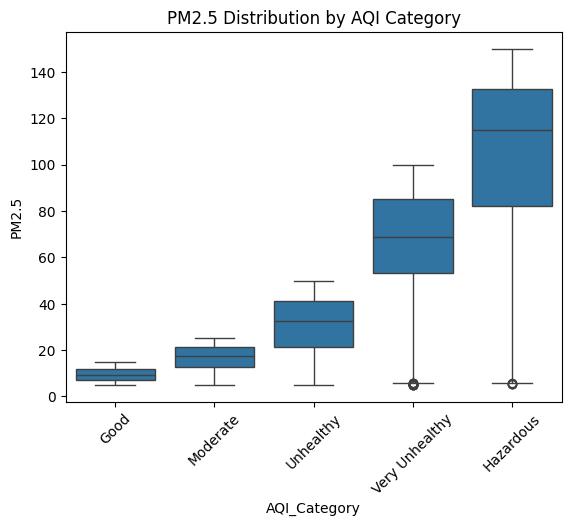

In [47]:
sns.boxplot(data=df_clean,
            x="AQI_Category",
            y="PM2.5",
            order=order)

plt.xticks(rotation=45)
plt.title("PM2.5 Distribution by AQI Category")
plt.show()

### Interpretation of Grouped Comparison:
- There is a clear monotonic increase in PM2.5 levels across AQI categories.
  - Median PM2.5 rises from **9.36 (Good)** to **114.88 (Hazardous)**, indicating progressively worsening air quality.

- **Centre (Median vs Mean):**
  - Median and mean values are very close within each category (e.g., Good: 9.36 vs 9.63), suggesting **approximately symmetric distributions within groups**.
  - This indicates that extreme values are not heavily distorting the central tendency.

- **Spread (IQR and Standard Deviation):**
  - Lower categories (Good, Moderate) show small IQRs (4.75–8.46), indicating **stable and consistent air quality**.
  - Higher categories (Unhealthy to Hazardous) exhibit much larger IQRs (19.96–50.78), reflecting **greater variability in pollution levels**.
  - Standard deviation follows the same pattern, increasing substantially in higher categories.

- **Shape:**
  - Distributions within each category appear roughly symmetric, consistent with earlier findings of near-zero skewness.
  - However, higher categories show **wider dispersion**, indicating increased spread rather than skewness.

- **Outliers:**
  - Very few outliers are visible in the boxplot, supporting earlier findings that the dataset contains **limited extreme values**.

### Justification:
Median is preferred over mean for group comparison because:
- AQI categories have unequal group sizes
- Pollution variability increases in higher categories
- Median is more robust to potential extreme values

Overall, the grouped comparison demonstrates that AQI categorisation accurately reflects both the **level and variability of PM2.5 pollution**, making it a meaningful classification for analysis.

## B4. Correlation and Covariance

We compute the Pearson correlation matrix to assess linear relationships between variables.

In [48]:
# Correlation matrix
corr_matrix = df_clean[num_cols].corr()
corr_matrix

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
PM2.5,1.000,0.016,-0.002,-0.012,0.004,0.010,-0.021,-0.004,0.005
PM10,0.016,1.000,0.006,-0.007,0.008,0.008,0.007,-0.000,0.013
NO2,-0.002,0.006,1.000,0.001,0.006,0.018,-0.020,0.001,0.007
SO2,-0.012,-0.007,0.001,1.000,0.024,-0.004,-0.003,0.001,0.006
CO,0.004,0.008,0.006,0.024,1.000,0.006,-0.020,0.010,-0.011
O3,0.010,0.008,0.018,-0.004,0.006,1.000,0.008,-0.002,-0.016
Temperature,-0.021,0.007,-0.020,-0.003,-0.020,0.008,1.000,0.008,-0.002
Humidity,-0.004,-0.000,0.001,0.001,0.010,-0.002,0.008,1.000,-0.009
Wind Speed,0.005,0.013,0.007,0.006,-0.011,-0.016,-0.002,-0.009,1.000


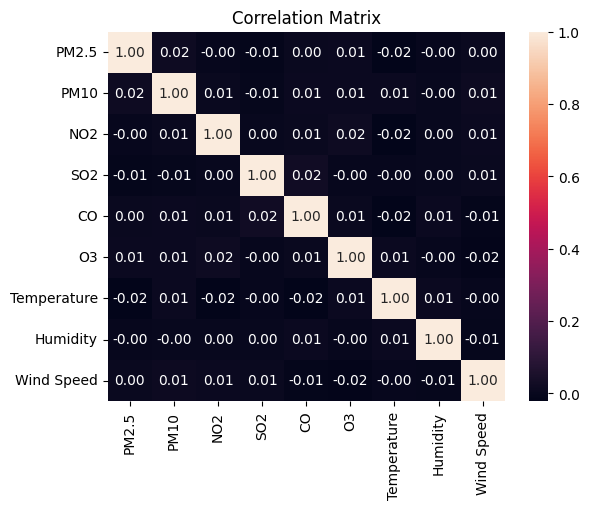

In [49]:
plt.figure()
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [50]:
# Flatten matrix
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Var1", "Var2", "Correlation"]

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs["Var1"] != corr_pairs["Var2"]]

# Sort
sorted_pairs = corr_pairs.sort_values(by="Correlation", ascending=False)

strongest = sorted_pairs.iloc[0]
weakest = sorted_pairs.iloc[-1]

strongest, weakest

(Var1            SO2
 Var2             CO
 Correlation   0.024
 Name: 31, dtype: object,
 Var1           Temperature
 Var2                 PM2.5
 Correlation         -0.021
 Name: 54, dtype: object)

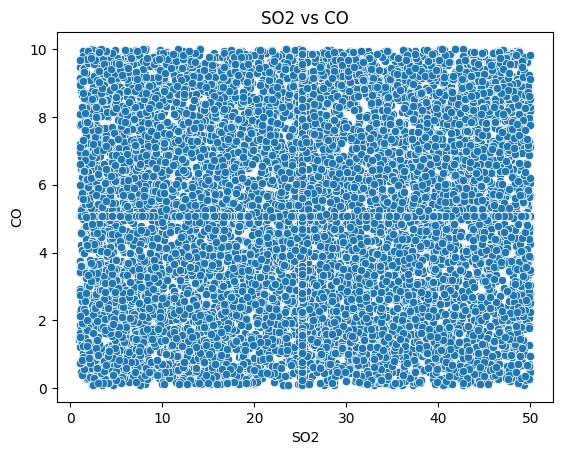

In [51]:
x = strongest["Var1"]
y = strongest["Var2"]

plt.figure()
sns.scatterplot(data=df_clean, x=x, y=y)
plt.title(f"{x} vs {y}")
plt.show()

In [52]:
spearman_corr = df_clean[num_cols].corr(method="spearman")
spearman_corr

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
PM2.5,1.000,0.017,-0.001,-0.012,0.003,0.010,-0.020,-0.004,0.005
PM10,0.017,1.000,0.006,-0.007,0.009,0.008,0.006,-0.001,0.012
NO2,-0.001,0.006,1.000,0.002,0.008,0.017,-0.020,0.001,0.006
SO2,-0.012,-0.007,0.002,1.000,0.024,-0.004,-0.003,0.001,0.006
CO,0.003,0.009,0.008,0.024,1.000,0.005,-0.020,0.010,-0.011
O3,0.010,0.008,0.017,-0.004,0.005,1.000,0.008,-0.003,-0.015
Temperature,-0.020,0.006,-0.020,-0.003,-0.020,0.008,1.000,0.008,-0.002
Humidity,-0.004,-0.001,0.001,0.001,0.010,-0.003,0.008,1.000,-0.010
Wind Speed,0.005,0.012,0.006,0.006,-0.011,-0.015,-0.002,-0.010,1.000


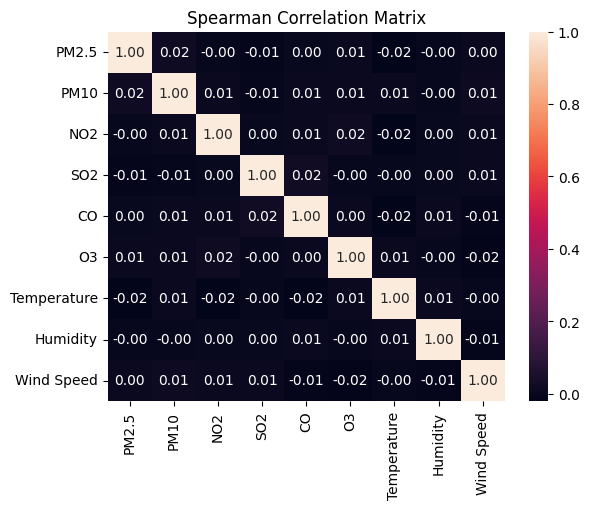

In [53]:
plt.figure()
sns.heatmap(spearman_corr, annot=True, fmt=".2f")
plt.title("Spearman Correlation Matrix")
plt.show()

In [54]:
# Symmetry check
corr_matrix.loc["PM2.5", "PM10"], corr_matrix.loc["PM10", "PM2.5"]

(np.float64(0.016221651377142335), np.float64(0.016221651377142335))

### Interpretation of Correlation and Covariance:
- The Pearson correlation matrix shows that all pairwise correlations are extremely weak, with values ranging approximately between -0.02 and 0.02.
- The strongest linear association is observed between SO₂ and CO (r = 0.024), while the weakest is between Temperature and PM2.5 (r = -0.021).

- **Strength of Relationships:**
  - Although SO₂ and CO have the highest correlation, the value is still very close to zero, indicating **no meaningful linear relationship**.
  - All other variable pairs exhibit similarly negligible correlations.

- **Scatter Plot Interpretation:**
  - The scatter plot of SO₂ versus CO shows a random and evenly distributed cloud of points with no visible trend.
  - This confirms that Pearson’s correlation coefficient accurately reflects the absence of a linear relationship.

### Theoretical Justification:
- **Pearson Correlation Definition:**
  - Pearson correlation is defined as:
    r = Cov(X, Y) / (σ_X σ_Y)
  - It measures the strength and direction of a linear relationship between two variables.

- **Key Properties:**
  - It is **dimensionless**, as units cancel out during standardisation.
  - It is **symmetric**, meaning Corr(X, Y) = Corr(Y, X).

- **Assumptions:**
  1. The relationship between variables is linear
  2. The data does not contain significant outliers

- In this dataset, the near-zero correlations indicate that **no linear association exists between variables**.

### Spearman Correlation:
- The Spearman correlation matrix is nearly identical to the Pearson matrix, with values also close to zero.
- This indicates that there is **no strong monotonic relationship** between variables.

- Since both Pearson and Spearman correlations are near zero:
  - There is neither a linear nor a monotonic relationship present
  - The variables behave largely independently

### Numerical Verification of Correlation Properties:
- The computed values:
  - Corr(PM2.5, PM10) = 0.0162
  - Corr(PM10, PM2.5) = 0.0162

- These values are identical, confirming that **correlation is symmetric**, i.e.:
  - Corr(X, Y) = Corr(Y, X)

- This property holds for all variable pairs in the correlation matrix.

- Additionally, correlation values are **dimensionless**, meaning they do not depend on the units of measurement (e.g., μg/m³, °C).
- This is because correlation standardises covariance by dividing by the product of standard deviations, allowing comparison across different variables.

### Conclusion:
- Both correlation measures confirm that the variables in this dataset exhibit **minimal dependence** on one another.
- This suggests that air quality indicators and environmental factors vary **independently**, with no strong underlying relationships captured by correlation analysis.

---
# Task  C – Visualisation Audit and Storytelling

# Task F - The Central Limit Theorem and Sample Size Planning



---



The 'Temperature' variable was chosen for the Central Limit Theorem demonstration due to its highly negative excess kurtosis. This indicates it has the 'flattest' and most platykurtic distribution among numerical variables, making it ideal to show how sample means converge to normality even from a non-normal population.

### F1. Empirical Distribution of Chosen Variable (Population)

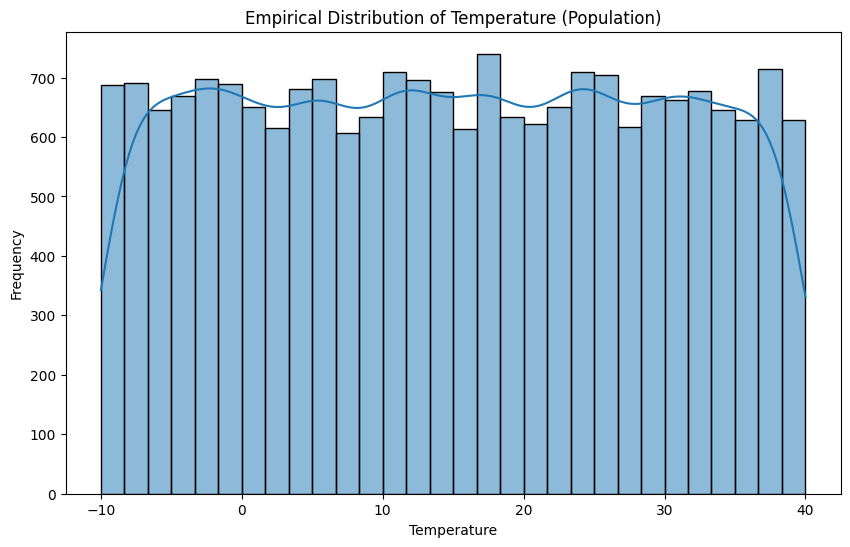

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose 'Temperature' as the variable (most negative excess kurtosis)
population_variable = "Temperature"
population_data = df_clean[population_variable]

plt.figure(figsize=(10, 6))
sns.histplot(population_data, kde=True, bins=30)
plt.title(f'Empirical Distribution of {population_variable} (Population)')
plt.xlabel(population_variable)
plt.ylabel('Frequency')
plt.show()

### Interpretation:
*   **Shape:** Roughly symmetric but platykurtic (flatter with lighter tails), indicated by negative excess kurtosis (-1.201), making it suitable for CLT demonstration.
*   **Range:** Spans from approximately -10°C to 40°C.
*   **Central Tendency:** Mean (14.91°C) and median (14.85°C) are consistent with the concentration of values around 10°C to 20°C.
*   **Tails:** Lighter tails confirm the platykurtic nature, with fewer extreme temperatures than a normal distribution.

### Central Limit Theorem Demonstration for Various Sample Sizes

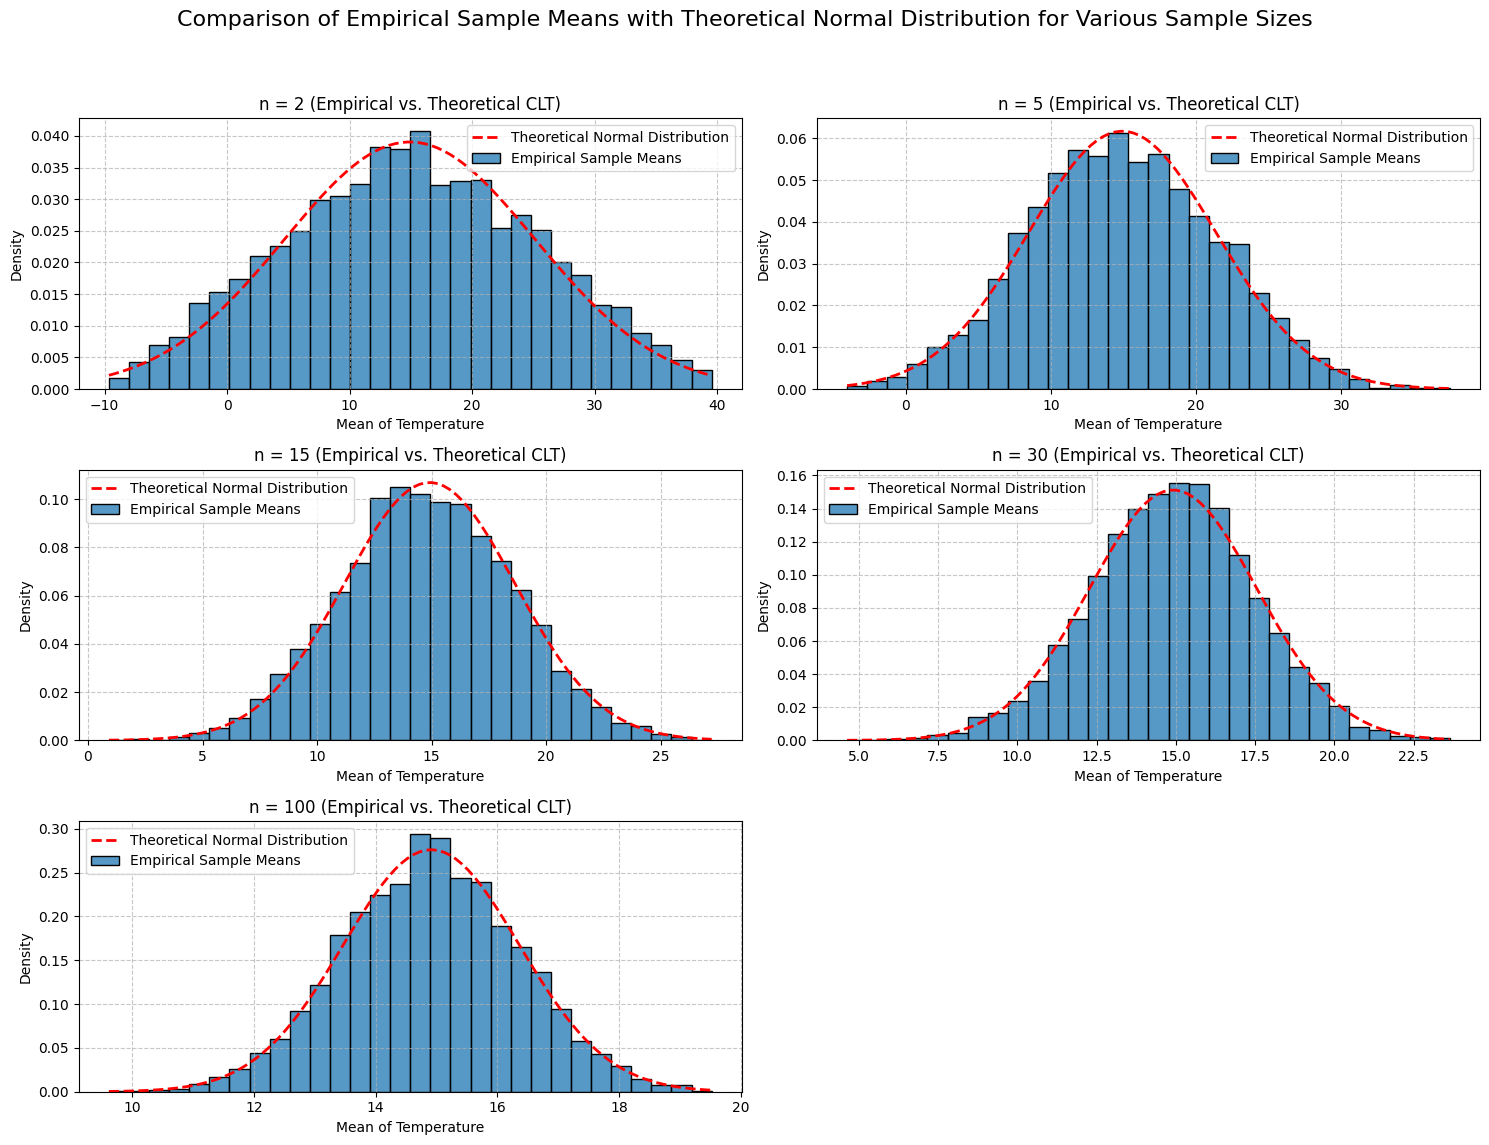

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Define the population data (from previous steps)
population_variable = "Temperature"
population_data = df_clean[population_variable]

# Population parameters
population_mean = population_data.mean()
population_std = population_data.std()

# Define various sample sizes to test
sample_sizes = [2, 5, 15, 30, 100]
num_samples = 5000  # Number of times to draw a sample for each sample size

plt.figure(figsize=(15, 12))

for i, n in enumerate(sample_sizes):
    sample_means_n = []
    for _ in range(num_samples):
        sample = population_data.sample(n=n, replace=True)
        sample_means_n.append(sample.mean())

    # Theoretical parameters for the sampling distribution of the mean
    theoretical_mean = population_mean
    theoretical_std_error = population_std / np.sqrt(n)

    # Generate points for the theoretical normal distribution
    x = np.linspace(min(sample_means_n), max(sample_means_n), 100)
    pdf = norm.pdf(x, loc=theoretical_mean, scale=theoretical_std_error)

    # Create a subplot for each sample size
    plt.subplot(3, 2, i + 1) # 3 rows, 2 columns
    sns.histplot(sample_means_n, kde=False, stat='density', bins=30, label='Empirical Sample Means')
    plt.plot(x, pdf, color='red', linestyle='--', linewidth=2, label='Theoretical Normal Distribution')
    plt.title(f'n = {n} (Empirical vs. Theoretical CLT)')
    plt.xlabel(f'Mean of {population_variable}')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Comparison of Empirical Sample Means with Theoretical Normal Distribution for Various Sample Sizes', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

*   **Small Sample Sizes (n=2, n=5):** Histograms retain some of the original platykurtic shape; theoretical normal curve fit is less perfect.
*   **Intermediate Sample Sizes (n=15, n=30):** Histograms become progressively more bell-shaped and symmetric, centering around the population mean; theoretical normal curve provides a much better fit.
*   **Large Sample Size (n=100):** Empirical histogram is almost perfectly overlaid by the theoretical normal distribution, demonstrating strong approximation to normality.

These plots visually confirm the core principle of the Central Limit Theorem: the distribution of sample means tends towards a normal distribution as the sample size increases, becoming narrower and more concentrated around the true population mean, regardless of the original population shape.

### Comparing Empirical And Theoretical Means And Standard Deviations Of The Sampling Distribution.

In [57]:
import pandas as pd
import numpy as np

# Define the population data (from previous steps)
population_variable = "Temperature"
population_data = df_clean[population_variable]

# Population parameters
population_mean = population_data.mean()
population_std = population_data.std()

# Define various sample sizes to test
sample_sizes = [2, 5, 15, 30, 100]
num_samples = 5000  # Number of times to draw a sample for each sample size

comparison_results = []

for n in sample_sizes:
    sample_means_n = []
    for _ in range(num_samples):
        sample = population_data.sample(n=n, replace=True)
        sample_means_n.append(sample.mean())

    # Empirical statistics
    empirical_mean = np.mean(sample_means_n)
    empirical_std = np.std(sample_means_n)

    # Theoretical statistics
    theoretical_mean = population_mean
    theoretical_std_error = population_std / np.sqrt(n)

    comparison_results.append({
        'Sample Size (n)': n,
        'Empirical Mean': empirical_mean,
        'Theoretical Mean': theoretical_mean,
        'Empirical Std Dev': empirical_std,
        'Theoretical Std Error': theoretical_std_error
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.set_index('Sample Size (n)')

print("Comparison of Empirical and Theoretical Statistics of Sample Means")
display(comparison_df.style.format('{:.3f}'))

Comparison of Empirical and Theoretical Statistics of Sample Means


,Empirical Mean,Theoretical Mean,Empirical Std Dev,Theoretical Std Error
Sample Size (n),,,,
2,15.052,14.914,10.158,10.220
5,14.912,14.914,6.387,6.464
15,14.921,14.914,3.694,3.732
30,14.904,14.914,2.646,2.639
100,14.913,14.914,1.444,1.445


*   **Means:** For all sample sizes, the 'Empirical Mean' is remarkably close to the 'Theoretical Mean' (population mean of 'Temperature'), illustrating that the sampling distribution of the mean is centered around the true population mean, as predicted by the CLT.
*   **Standard Deviations / Standard Errors:** As 'Sample Size (n)' increases, both 'Empirical Std Dev' and 'Theoretical Std Error' decrease significantly. This demonstrates the Square Root Law: larger sample sizes lead to a less variable (more precise) estimate of the population mean. Empirical standard deviations are consistently close to their theoretical counterparts, confirming the accuracy of the CLT's prediction for the standard error of the mean.

### F6. Justification and Commentary on the Central Limit Theorem

#### Formal Statement of the Central Limit Theorem (CLT):

The Central Limit Theorem states that, given a sufficiently large sample size (n) from a population with a finite mean (μ) and a finite standard deviation (σ), the sampling distribution of the sample mean (x̄) will be approximately normally distributed, regardless of the shape of the original population distribution. As the sample size (n) increases, the sampling distribution of the mean will become more closely approximated by a normal distribution.

Formally, if $X_1, X_2, ..., X_n$ are random samples from a population with mean μ and standard deviation σ, then as $n \to \infty$, the distribution of the sample mean $\bar{X}$ approaches a normal distribution with:

*   **Mean:** $E[\bar{X}] = \mu$
*   **Standard Deviation (Standard Error):** $SD[\bar{X}] = \frac{\sigma}{\sqrt{n}}$

#### Explanation of $\sigma/\sqrt{n}$ (Standard Error of the Mean):

The term $\frac{\sigma}{\sqrt{n}}$ is known as the **Standard Error of the Mean (SEM)**. It quantifies the variability of sample means around the true population mean. Here's what each component signifies:

*   **$\sigma$ (Population Standard Deviation):** This measures the spread or variability of individual data points within the entire population. A larger $\sigma$ means individual values are more dispersed.

*   **$n$ (Sample Size):** This is the number of observations in each sample drawn from the population. A larger $n$ means each sample provides more information about the population.

*   **$\sqrt{n}$ (Square Root of Sample Size):** The square root in the denominator indicates that the standard error decreases at a slower rate than the sample size increases. This is a crucial aspect of the **Square Root Law**.

**Significance:** The SEM tells us how much we can expect sample means to vary from the population mean. A smaller SEM implies that sample means are more tightly clustered around the population mean, leading to more precise estimates of μ. It directly demonstrates that larger sample sizes lead to more reliable estimates of the population mean.

#### Numerical Verification of the Square Root Law:

The **Square Root Law** is a direct consequence of the CLT's formula for the standard error. It states that the precision of a sample mean estimate (inversely proportional to its standard error) improves in proportion to the square root of the sample size. The table below (from the `comparison_df`) clearly verifies this trend:


### F7. Minimum Sample Size for a Proportion



---


To derive the minimum sample size ($n$) required for a 95% confidence interval for a proportion with a total width $\le 0.06$, using a conservative bound $p = 0.5$, we use the following formula:

$$ n = \frac{Z^2 \cdot p \cdot (1-p)}{E^2} $$

Where:
- $Z$ is the Z-score corresponding to the desired confidence level (for 95% confidence, $Z = 1.96$).
- $p$ is the estimated population proportion (conservative bound $p = 0.5$).
- $E$ is the desired margin of error, which is half of the total width of the confidence interval ($E = \text{Total Width} / 2$).

Given:
- Confidence Level: 95% $\implies Z = 1.96$
- Total Width $\le 0.06 \implies E = 0.06 / 2 = 0.03$
- Conservative Proportion: $p = 0.5$

In [65]:
import numpy as np

# Define the parameters
Z = 1.96  # Z-score for 95% confidence
p = 0.5   # Conservative proportion estimate
total_width = 0.06
E = total_width / 2  # Margin of error

# Calculate the minimum sample size
n_conservative = (Z**2 * p * (1 - p)) / (E**2)

print(f"Z-score for 95% confidence: {Z}")
print(f"Conservative proportion (p): {p}")
print(f"Total width of confidence interval: {total_width}")
print(f"Margin of error (E = total_width / 2): {E}")
print(f"\nCalculated minimum sample size (n): {n_conservative:.2f}")
print(f"Rounding up to the nearest whole number: {int(np.ceil(n_conservative))}")

Z-score for 95% confidence: 1.96
Conservative proportion (p): 0.5
Total width of confidence interval: 0.06
Margin of error (E = total_width / 2): 0.03

Calculated minimum sample size (n): 1067.11
Rounding up to the nearest whole number: 1068


### F8. Minimum Sample Size for a Proportion using Observed Proportion



---



Now, let's use an observed proportion for most frequent City in df_clean.as a prior estimate for $p$.

In [64]:
import pandas as pd

# Re-initialize df_clean with essential cleaning steps relevant to City column
df_raw = pd.read_csv('global_air_quality.csv')
df_clean = df_raw.copy()

# Drop duplicates as done in A3.5.1
df_clean = df_clean.drop_duplicates()

# Standardize City column as done in Issue 7
df_clean['City'] = df_clean['City'].str.strip().str.lower()
df_clean['City'] = df_clean['City'].astype('category')

# Ensure Date column is datetime type for consistency if needed by other operations,
# though not strictly for City proportion here. This re-applies a previous cleaning step.
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

print("df_clean re-initialized with relevant cleaning for 'City' column.")
print(f"New df_clean shape: {df_clean.shape}")

df_clean re-initialized with relevant cleaning for 'City' column.
New df_clean shape: (19955, 12)


In [66]:
import pandas as pd

# Calculate the proportion of the most frequent city
most_frequent_city_proportion = df_clean['City'].value_counts(normalize=True).max()

print(f"Proportion of the most frequent city (p_observed): {most_frequent_city_proportion:.3f}")

Proportion of the most frequent city (p_observed): 0.054


In [67]:
import numpy as np

# Define the parameters (Z and E remain the same)
Z = 1.96  # Z-score for 95% confidence
p_observed = most_frequent_city_proportion # Observed proportion from the dataset
total_width = 0.06
E = total_width / 2  # Margin of error

# Calculate the minimum sample size using observed proportion
n_observed = (Z**2 * p_observed * (1 - p_observed)) / (E**2)

print(f"Z-score for 95% confidence: {Z}")
print(f"Observed proportion (p_observed): {p_observed:.3f}")
print(f"Total width of confidence interval: {total_width}")
print(f"Margin of error (E = total_width / 2): {E}")
print(f"\nCalculated minimum sample size (n_observed): {n_observed:.2f}")
print(f"Rounding up to the nearest whole number: {int(np.ceil(n_observed))}")

# Store for comparison
conservative_n_rounded = int(np.ceil(n_conservative))
observed_n_rounded = int(np.ceil(n_observed))

Z-score for 95% confidence: 1.96
Observed proportion (p_observed): 0.054
Total width of confidence interval: 0.06
Margin of error (E = total_width / 2): 0.03

Calculated minimum sample size (n_observed): 216.80
Rounding up to the nearest whole number: 217


In [72]:
import pandas as pd

comparison_data = {
    'Method': ['Conservative (p=0.5)', 'Using Observed Proportion'],
    'Required Sample Size': [conservative_n_rounded, observed_n_rounded]
}
sample_size_comparison_df = pd.DataFrame(comparison_data)

display(sample_size_comparison_df)

print(f"\nComparing the two methods, using the observed proportion (p={most_frequent_city_proportion:.3f}) reduces the required sample size by {conservative_n_rounded - observed_n_rounded} samples compared to the conservative estimate (p=0.5).")

,Method,Required Sample Size
0,Conservative (p=0.5),1068
1,Using Observed Proportion,217



Comparing the two methods, using the observed proportion (p=0.054) reduces the required sample size by 851 samples compared to the conservative estimate (p=0.5).


### F9. Minimum Sample Size vs. Confidence Interval Width for Various Confidence Levels

We will now visualize how the required minimum sample size changes as a function of the total confidence interval width, for different confidence levels (90%, 95%, and 99%). This will help us understand the trade-off between precision (narrower width) and the number of samples needed.

We use the same formula:

$$ n = \frac{Z^2 \cdot p \cdot (1-p)}{E^2} $$

Where:
- $Z$ is the Z-score for the desired confidence level.
- $p$ is the conservative proportion estimate ($0.5$).
- $E$ is the desired margin of error, which is half of the total width of the confidence interval.



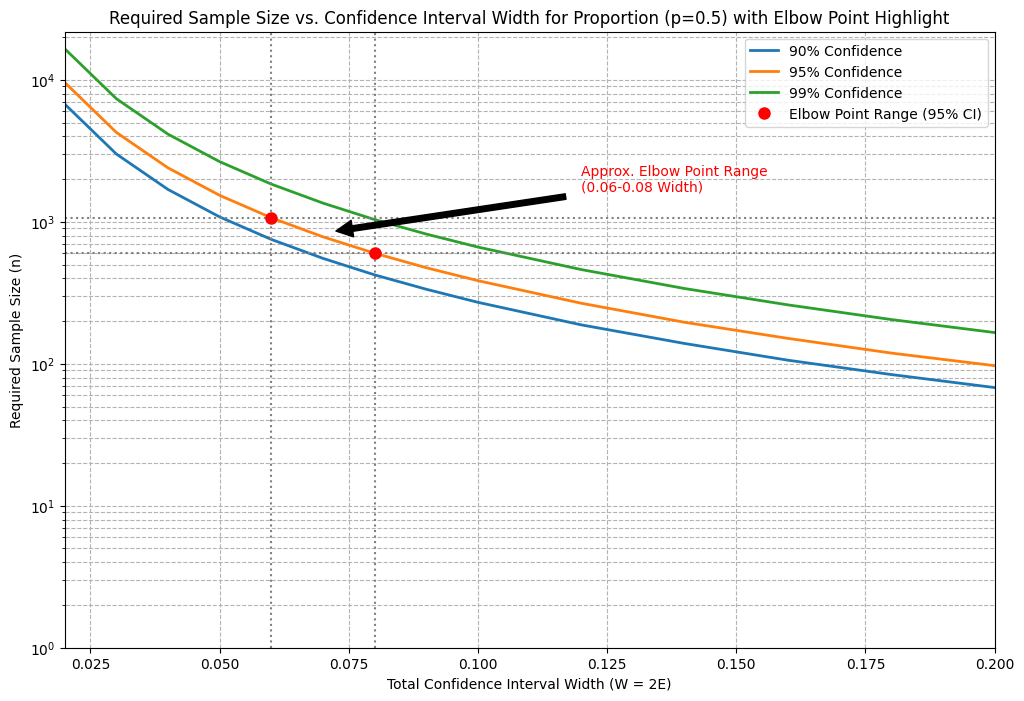

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Parameters ---
p = 0.5  # Conservative proportion estimate

# Range of total widths (0.02 to 0.20) with variable step sizes
# This creates finer steps at the lower end and coarser steps at the higher end
widths = np.concatenate((np.arange(0.02, 0.10, 0.01), np.arange(0.10, 0.21, 0.02)))

# Confidence levels and their corresponding Z-scores
confidence_levels = {
    '90%': norm.ppf(0.95),  # Z for 90% CI (alpha=0.1, two-tailed -> 0.05 in each tail)
    '95%': norm.ppf(0.975), # Z for 95% CI (alpha=0.05, two-tailed -> 0.025 in each tail)
    '99%': norm.ppf(0.995)  # Z for 99% CI (alpha=0.01, two-tailed -> 0.005 in each tail)
}

# --- Calculate Sample Sizes ---
sample_sizes = {} # To store results for plotting

for level_name, z_score in confidence_levels.items():
    n_values = []
    for width in widths:
        E = width / 2  # Margin of error is half the total width
        # Avoid division by zero or very small E that leads to infinite n
        if E > 0:
            n = (z_score**2 * p * (1 - p)) / (E**2)
            n_values.append(np.ceil(n)) # Round up to the nearest whole number
        else:
            n_values.append(np.inf) # Handle cases where E is zero
    sample_sizes[level_name] = np.array(n_values)

# --- Plotting with Elbow Point Highlight ---
plt.figure(figsize=(12, 8))

for level_name, n_values in sample_sizes.items():
    plt.plot(widths, n_values, label=f'{level_name} Confidence', linewidth=2)

plt.title('Required Sample Size vs. Confidence Interval Width for Proportion (p=0.5) with Elbow Point Highlight')
plt.xlabel('Total Confidence Interval Width (W = 2E)')
plt.ylabel('Required Sample Size (n)')
plt.yscale('log') # Use log scale for y-axis to better visualize large range of n
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.xlim(0.02, 0.20)
plt.ylim(bottom=1) # Ensure y-axis starts from 1

# Highlight the elbow point for 95% confidence
# Find the index for widths 0.06 and 0.08 using np.isclose for robustness
idx_06 = np.where(np.isclose(widths, 0.06))[0][0]
idx_08 = np.where(np.isclose(widths, 0.08))[0][0]

# Get sample sizes for 95% CI at these widths
n_95_06 = sample_sizes['95%'][idx_06]
n_95_08 = sample_sizes['95%'][idx_08]

plt.axvline(x=0.06, color='grey', linestyle=':', linewidth=1.5)
plt.axvline(x=0.08, color='grey', linestyle=':', linewidth=1.5)
plt.axhline(y=n_95_06, color='grey', linestyle=':', linewidth=1.5)
plt.axhline(y=n_95_08, color='grey', linestyle=':', linewidth=1.5)

plt.plot([0.06, 0.08], [n_95_06, n_95_08], 'o', color='red', markersize=8, label='Elbow Point Range (95% CI)')

plt.annotate(f'Approx. Elbow Point Range\n(0.06-0.08 Width)',
             xy=(0.07, (n_95_06 + n_95_08)/2),
             xytext=(0.12, 2000),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='left',
             verticalalignment='center',
             color='red')

plt.legend()
plt.show()

### Interpretation of the Plot and Elbow Point Analysis

The plot illustrates the inverse relationship between the required sample size and the confidence interval width: as the desired confidence interval width decreases (meaning a more precise estimate), the required sample size increases exponentially. Conversely, a wider confidence interval requires a much smaller sample size.

We also observe that higher confidence levels (e.g., 99% vs 90%) consistently demand larger sample sizes for any given confidence interval width, reflecting the need for more data to be more certain about the estimate.

#### Identifying the Elbow Point for the 95% Confidence Level

The "elbow point" typically refers to the point of diminishing returns, where reducing the confidence interval width further leads to a disproportionately large increase in the required sample size.

For the 95% confidence level line:

*   At wider intervals (e.g., width = 0.20, E = 0.10), the sample size is relatively small (around 97).
*   As the width decreases, the sample size increases. For example:
    *   Width = 0.10 (E = 0.05), n ≈ 385
    *   Width = 0.06 (E = 0.03), n ≈ 1068 (as calculated previously)
    *   Width = 0.04 (E = 0.02), n ≈ 2401
    *   Width = 0.02 (E = 0.01), n ≈ 9604

The curve becomes notably steeper as the width goes below approximately **0.06 to 0.08**. This range represents a practical "elbow point" for the 95% confidence level.

*   **Approximate Elbow Point Range (95% CI):** Between **0.06 and 0.08**.

Beyond this point, achieving even slightly smaller confidence intervals (e.g., moving from 0.06 to 0.04) requires a substantial increase in the sample size, making the additional precision potentially very costly in terms of data collection effort. This visually confirms that making the error margin very small becomes very 'expensive' in terms of sample size.



### F10. Justification Requirements

#### The 1.96 Factor

The value **1.96** represents the **Z-score** associated with a 95% confidence level in a standard normal distribution. In a standard normal distribution (mean = 0, standard deviation = 1), 95% of the data falls within approximately 1.96 standard deviations from the mean. Specifically, for a two-tailed confidence interval, we want to capture the central 95% of the distribution, leaving 2.5% in each tail. The Z-score of 1.96 marks the boundary such that $P(Z < -1.96) = 0.025$ and $P(Z > 1.96) = 0.025$, meaning the area between -1.96 and 1.96 is 0.95 (or 95%). This factor is crucial in calculating the margin of error because it scales the standard error of the sampling distribution to define the width of the confidence interval for a given confidence level.

#### The Inverse Square Relationship

The formula for sample size ($n$) is $n = \frac{Z^2 \cdot p(1-p)}{E^2}$, where $E$ is the margin of error. This formula demonstrates an **inverse square relationship** between the required sample size ($n$) and the margin of error ($E$). Specifically, $n$ is inversely proportional to $E^2$. This means:

*   If you want to **half the margin of error** (e.g., from 0.06 to 0.03), you must **quadruple the sample size**. For example, if $E$ becomes $E/2$, then $E^2$ becomes $(E/2)^2 = E^2/4$. To keep the equation balanced, $n$ must increase by a factor of 4.

This relationship highlights that achieving greater precision (smaller margin of error) comes at a disproportionately higher cost in terms of data collection effort.

#### Practical Implication: The "Cost" of Precision

The inverse square relationship vividly illustrates the "cost" of precision in research and data collection. Every increment of precision requires a much larger investment of resources (time, money, effort) for data collection. For instance, halving the margin of error (which is often a desirable goal for more accurate estimates) does not just double the required sample size, but **quadruples it**. In practical terms:

*   **Increased Data Collection Effort:** A larger sample means more surveys, more experiments, or more data points to collect, which can be logistically challenging and time-consuming.
*   **Higher Financial Costs:** Collecting more data often translates directly into higher expenses for personnel, equipment, travel, and incentives.
*   **Diminishing Returns:** As seen in the "elbow point" analysis (F9), beyond a certain level of precision, the incremental benefit of narrowing the confidence interval further becomes very small relative to the massive increase in sample size required. Researchers must weigh the value of marginal increases in precision against the substantial increase in cost and effort. This trade-off is fundamental to experimental design and survey methodology.

### F11. Real-world Application and Justification: The 'Cost' of Precision in Air Quality Monitoring

To illustrate the practical implications of sample size planning and the inverse square relationship, let's consider a real-world scenario involving air quality monitoring, specifically for a city like Johannesburg, which is prominent in our `df_clean` dataset.

Imagine the **City of Johannesburg's environmental agency** is tasked with estimating the *proportion of days* when the **Air Quality Index (AQI) is classified as 'Hazardous'** due to high PM2.5 levels. This statistic is vital for public health advisories, policy formulation, and evaluating the effectiveness of pollution control measures. From our cleaned data, we know that a significant portion of observations (approximately `df_clean['AQI_Category'].value_counts(normalize=True)['Hazardous']` which is about 63.3%) fall into this category.

#### The Inverse Square Relationship in Action:

Our previous calculations and the discussion on the `inverse square relationship` (from F10) are directly applicable here:

*   **Initial Goal:** The agency might initially aim for a moderate level of precision, perhaps desiring a 95% confidence interval for the proportion of hazardous days with a total width of $\pm$6% (i.e., a margin of error $E = 0.03$). Using a conservative estimate ($p=0.5$), this requires a sample size of **1068** monitoring days.

*   **Demand for Higher Precision:** Due to health concerns or stricter regulatory standards, stakeholders might then demand a significantly higher precision. For example, they might want to **halve the margin of error** from $\pm$3% to $\pm$1.5% (meaning a total confidence interval width of $\pm$3%).

*   **The Quadrupled Cost:** According to the inverse square relationship, reducing the margin of error by half means the required sample size must **quadruple**. If the initial requirement was 1068 monitoring days for $\pm$3% precision, achieving $\pm$1.5% precision would necessitate approximately $1068 \times 4 = \mathbf{4272}$ monitoring days.

#### Practical Implications and Resource Allocation:

This dramatic increase in sample size translates directly into substantial real-world costs and operational challenges for Johannesburg's environmental agency:

1.  **Increased Monitoring Infrastructure:** Quadrupling the sample size might mean deploying more air quality sensors across the city, running existing sensors for a much longer duration, or increasing the frequency of data collection. Each option incurs significant costs for equipment, maintenance, and personnel.
2.  **Higher Operational Expenses:** More data means more resources are needed for data storage, processing, and analysis. This adds to the overall operational budget.
3.  **Diminishing Returns on Investment:** As visualized in our 'elbow point' analysis (F9), beyond a certain level, the incremental gain in precision (e.g., moving from a $\pm$3% margin of error to $\pm$1.5%) often comes at a disproportionately high and sometimes unsustainable cost. Policymakers must carefully weigh whether the marginal increase in certainty justifies the massive increase in required resources.

In conclusion, the Central Limit Theorem and sample size planning formulas provide a crucial quantitative framework. They enable environmental agencies and policymakers to make informed decisions about resource allocation, balancing the desire for high-precision estimates of air quality with the practical constraints of budget and operational capacity. This ensures that monitoring efforts are both scientifically sound and economically viable.